In [1]:
import os
os.chdir('../../..')

In [2]:
import re
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import kmedoids
import chemiscope

from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.manifold import TSNE
from tqdm import tqdm
from umap import UMAP
from persim import plot_diagrams

from src.datasets import QM9Dataset
from src.features import MolecularFeaturizer
from src.non_euclidean import Grassmann, Riemann, PersistentHomology

In [3]:
qm9 = QM9Dataset()
qm9.load()
qm9.add_soap()

2026-03-17 15:03:01.005 | INFO     | src.datasets:load:132 - Loading QM9 from data/QM9/dataset_cleaned.csv...
2026-03-17 15:03:01.032 | INFO     | src.features:compute_soap:144 - Computing SOAP (rcut=6.0, nmax=8, lmax=6)...
2026-03-17 15:03:06.091 | SUCCESS  | src.datasets:add_soap:423 - Added SOAP embeddings.


In [4]:
qm9.df.head(3)

mol_id,formula,smiles,canonical_smiles,selfies,functional_groups,num_atoms,structure_class,mol_weight,logp,tpsa,num_heavy_atoms,num_rings,num_aromatic_rings,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,soap_embedding
str,str,str,str,str,str,i64,str,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[f64]
"""qm9_0""","""CH4""","""[H]C([H])([H])[H]""","""[H]C([H])([H])[H]""","""[H][C][Branch1][C][H][Branch1]…","""""",5,"""Acyclic""",16,0,0,1,0,0,0,0.0,0.0,1.0,0,0,1,0,0,1,2,9,1.103448,0,0,0,0,0,0,0,0,0,0,0,0.0,13.21,-10.549854,3.186453,13.736308,35.364101,1.217682,-1101.487793,-1101.40979,-1101.384033,-1102.022949,6.469,-17.172182,-17.286823,-17.389656,-16.151918,157.711807,157.709976,157.706985,"[0.184413, 0.478464, … 0.0]"
"""qm9_1""","""H3N""","""[H]N([H])[H]""","""[H]N([H])[H]""","""[H][N][Branch1][C][H][H]""","""""",4,"""Acyclic""",17,0,35,1,0,0,0,0.0,0.0,0.0,1,1,1,0,0,0,2,6,1.039883,0,0,0,0,0,0,0,0,0,0,1,1.6256,9.46,-6.993326,2.255824,9.249149,26.1563,0.934929,-1538.147705,-1538.069824,-1538.044189,-1538.666748,6.316,-12.005855,-12.082129,-12.159273,-11.246005,293.609741,293.541107,191.393967,"[0.170095, 0.427155, … 0.0]"
"""qm9_2""","""H2O""","""[H]O[H]""","""[H]O[H]""","""[H][O][H]""","""""",3,"""Acyclic""",18,0,31,1,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,2,3,0.980759,0,0,0,0,0,0,0,0,0,0,1,1.8511,6.31,-7.967494,1.869422,9.836916,19.0002,0.581643,-2079.077881,-2079.000732,-2078.975098,-2079.558105,6.002,-9.240362,-9.278811,-9.330214,-8.733849,799.588135,437.90387,282.945465,"[0.150713, 0.392522, … 0.0]"


In [5]:
row = 0
num_molecules = None

# add molecular formula to find isomers
df = qm9.df

min_isomers = 30
formula_counts = df.group_by("formula").len().sort("len", descending=True)

display(formula_counts.head(10))

eligible = formula_counts.filter(pl.col("len") >= min_isomers)
if eligible.is_empty():
    raise ValueError(f"No formulas found with at least {min_isomers} isomers")

target_formula = eligible.row(row)[0]

isomers_df = df.filter(pl.col("formula") == target_formula)

def format_chemical(formula):
    return re.sub(r'(\d+)', lambda m: m.group(1).translate(str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")), formula)

print(f"Selected formula: {format_chemical(target_formula)} (n={isomers_df.height})")

formula,len
str,u32
"""C6H10O""",88
"""C5H8O2""",80
"""C5H7NO""",79
"""C5H10O2""",79
"""C6H12O""",63
"""C4H6N2O""",54
"""C4H5NO2""",48
"""C6H8O""",48
"""C4H7NO2""",45


Selected formula: C₆H₁₀O (n=88)


In [6]:
isomers_df.head(5)

mol_id,formula,smiles,canonical_smiles,selfies,functional_groups,num_atoms,structure_class,mol_weight,logp,tpsa,num_heavy_atoms,num_rings,num_aromatic_rings,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,soap_embedding
str,str,str,str,str,str,i64,str,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[f64]
"""qm9_1056""","""C6H10O""","""[H]OC(C#CC([H])([H])[H])(C([H]…","""[H]OC(C#CC([H])([H])[H])(C([H]…","""[H][O][C][Branch1][O][C][#C][C…","""alcohol""",17,"""Acyclic""",98,0,20,7,0,0,3,0.333333,0.0,0.666667,1,1,4,2,0,4,6,33,1.221356,0,1,0,0,0,0,0,0,0,0,1,1.3077,69.099998,-6.601482,1.366012,7.967494,1005.311523,3.931338,-8427.34668,-8427.092773,-8427.066406,-8428.299805,32.465,-69.425476,-69.826736,-70.238007,-64.698151,4.63514,1.37628,1.36228,"[0.135988, 0.361658, … 0.0]"
"""qm9_1059""","""C6H10O""","""[H]C#CC([H])([H])C(O[H])(C([H]…","""[H]C#CC([H])([H])C(O[H])(C([H]…","""[H][C][#C][C][Branch1][C][H][B…","""alcohol""",17,"""Acyclic""",98,0,20,7,0,0,4,0.333333,0.0,0.666667,1,1,4,2,0,4,6,33,1.221311,0,1,0,0,0,0,0,0,0,0,1,1.8257,65.739998,-6.963394,1.390502,8.353896,842.739197,3.930902,-8427.166016,-8426.927734,-8426.902344,-8428.041992,32.365002,-69.244415,-69.661972,-70.073242,-64.440979,4.55848,1.70964,1.67157,"[0.136008, 0.365263, … 0.0]"
"""qm9_1103""","""C6H10O""","""[H]C([H])([H])C1(C([H])([H])[H…","""[H]C([H])([H])C1(C([H])([H])[H…","""[H][C][Branch1][C][H][Branch1]…","""ketone""",17,"""Aliphatic Ring""",98,1,17,7,1,0,2,0.0,0.166667,0.833333,0,1,6,0,1,5,5,37,1.250139,0,0,0,0,0,0,0,1,0,0,1,2.9233,64.370003,-6.492637,-0.465315,6.027322,792.775574,3.977679,-8428.405273,-8428.200195,-8428.174805,-8429.266602,28.490999,-70.484489,-70.933968,-71.345238,-65.66497,4.92901,1.86219,1.77689,"[0.136381, 0.364002, … 0.0]"
"""qm9_1135""","""C6H10O""","""[H]C#CC(C([H])([H])[H])(C([H])…","""[H]C#CC(C([H])([H])[H])(C([H])…","""[H][C][#C][C][Branch1][=Branch…","""alcohol""",17,"""Acyclic""",98,0,20,7,0,0,4,0.333333,0.0,0.666667,1,1,4,2,0,4,6,33,1.221662,0,1,0,0,0,0,0,0,0,0,1,1.2828,65.860001,-7.080402,1.428598,8.509001,820.219421,3.94663,-8426.979492,-8426.738281,-8426.711914,-8427.859375,32.249001,-69.058395,-69.472282,-69.883553,-64.258087,3.943,1.84396,1.74441,"[0.13586, 0.365704, … 0.0]"
"""qm9_1145""","""C6H10O""","""[H]C#C[C@@](O[H])(C([H])([H])[…","""[H]C#C[C@@](O[H])(C([H])([H])[…","""[H][C][#C][C@@][Branch1][Ring1…","""alcohol""",17,"""Acyclic""",98,0,20,7,0,0,4,0.333333,0.0,0.666667,1,1,4,2,0,4,6,33,1.22371,0,1,0,0,0,0,0,0,0,0,1,1.1577,65.989998,-7.153873,1.039475,8.19607,834.219421,3.941651,-8427.080078,-8426.841797,-8426.816406,-8427.958984,32.264,-69.158974,-69.575737,-69.986984,-64.356621,4.01944,1.84116,1.71261,"[0.136103, 0.365307, … 0.0]"


In [7]:
original_df = qm9.df
qm9.df = isomers_df
frames = qm9.get_positions(
    subset_size=isomers_df.height,
    output_filename="qm9_isomers.xyz"
)
qm9.df = original_df

print(f"Generated {len(frames)} frames for isomer set")

2026-03-17 15:03:06.662 | SUCCESS  | src.datasets:get_positions:709 - Saved 88 molecules to data/QM9/qm9_isomers.xyz (failed: 0, requested: 88).


Generated 88 frames for isomer set


In [8]:
# grassmann distance on ASE frames
grassmann_dist = Grassmann.distance_matrix(frames)
riemann_dist = Riemann.distance_matrix(frames, 'affine-invariant')
ph_dist = PersistentHomology.distance_matrix(frames, 'sliced-wasserstein')

# SOAP features from SMILES
soap_series = MolecularFeaturizer.compute_soap(isomers_df["canonical_smiles"])
soap_list = soap_series.to_list()

valid_idx = [i for i, v in enumerate(soap_list) if v is not None]

if len(valid_idx) < 3:
    raise ValueError("Too few valid SOAP features to cluster")

isomers_df = isomers_df[valid_idx]

frames = [frames[i] for i in valid_idx]
grassmann_dist = grassmann_dist[np.ix_(valid_idx, valid_idx)]

2026-03-17 15:03:06.672 | INFO     | src.non_euclidean:distance_matrix:337 - Computing Grassmann distance matrix for 88 frames (k=3, method='svd', normalized=False).
Grassmann distances: 100%|██████████| 3828/3828 [00:00<00:00, 13337.05pair/s]
2026-03-17 15:03:07.036 | SUCCESS  | src.non_euclidean:distance_matrix:351 - Finished Grassmann distance matrix computation.
2026-03-17 15:03:07.037 | INFO     | src.non_euclidean:distance_matrix:460 - Computing Riemannian distance matrix for 88 frames (metric='affine-invariant', normalized=False)
Riemann distances: 100%|██████████| 3828/3828 [00:00<00:00, 61169.36pair/s]
2026-03-17 15:03:07.143 | SUCCESS  | src.non_euclidean:distance_matrix:524 - Finished Riemannian distance matrix computation.
2026-03-17 15:03:07.144 | INFO     | src.non_euclidean:distance_matrix:262 - Computing persistent homology distance matrix for 88 frames (metric='sliced-wasserstein', max_homology_dim=2, dims=(0, 1, 2)).
2026-03-17 15:03:07.144 | INFO     | src.non_euclid

In [9]:
soap_dist = squareform(pdist(soap_list, metric='cosine'))

In [10]:
def evaluate_clustering_methods(distance_matrices, k_range=range(2, 15), random_state=42):
    results = {name: {"inertia": [], "silhouette": [], "ch": []} for name in distance_matrices}

    for k in tqdm(k_range, desc="Testing Cluster Counts"):
        for name, dist_matrix in distance_matrices.items():
            
            model = kmedoids.KMedoids(n_clusters=k, metric="precomputed", random_state=random_state)
            labels = model.fit_predict(dist_matrix)
            medoid_indices = model.medoid_indices_
            
            inertia = sum(dist_matrix[i, medoid_indices[labels[i]]] for i in range(len(labels)))
            
            sil = silhouette_score(dist_matrix, labels, metric='precomputed')
            
            ch = calinski_harabasz_score(dist_matrix, labels)

            results[name]["inertia"].append(inertia)
            results[name]["silhouette"].append(sil)
            results[name]["ch"].append(ch)
            
    return results

matrices = {
    "Grassmann": grassmann_dist,
    "Riemann": riemann_dist,
    "SOAP": soap_dist,
    "Persistent Homology": ph_dist  
}
k_range = range(2, 15)
evaluation_results = evaluate_clustering_methods(matrices, k_range)

Testing Cluster Counts: 100%|██████████| 13/13 [00:00<00:00, 243.91it/s]


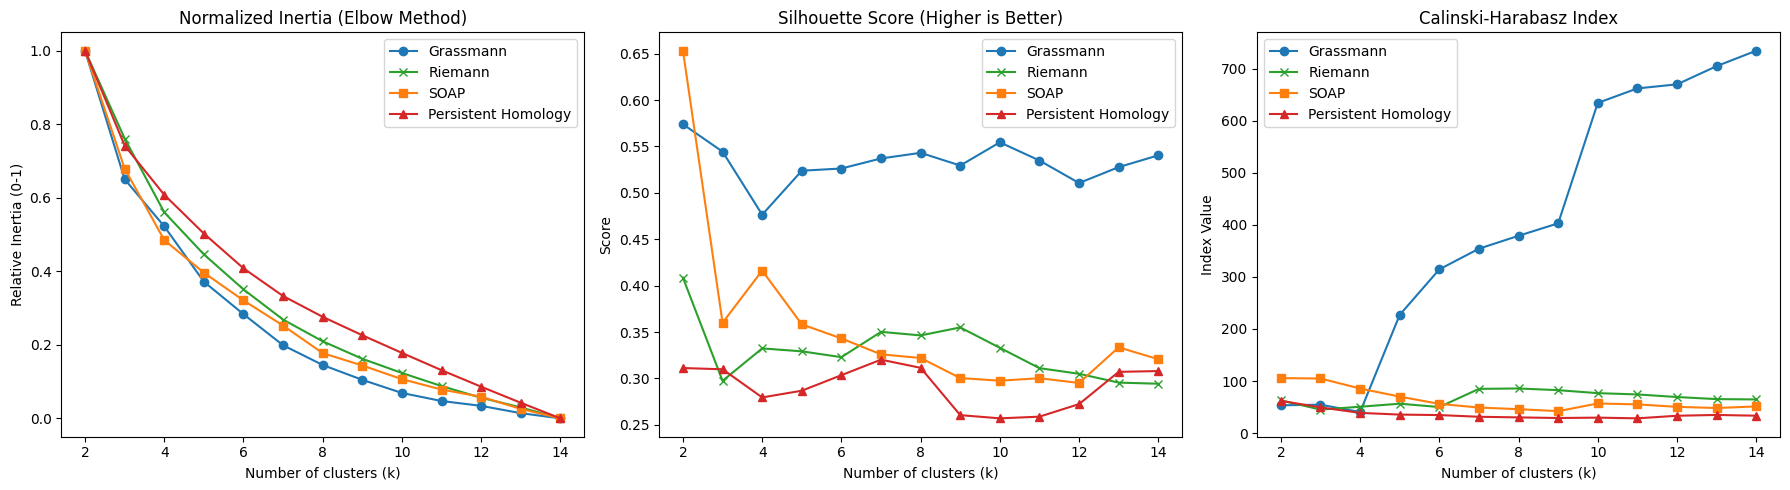

In [11]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {'Grassmann': 'tab:blue', 'Riemann': 'tab:green', 
          'SOAP': 'tab:orange', 'Persistent Homology': 'tab:red'}
markers = {'Grassmann': 'o', 'Riemann': 'x', 
           'SOAP': 's', 'Persistent Homology': '^'}

ax0 = axes[0]
for name in evaluation_results:
    raw_inertia = np.array(evaluation_results[name]["inertia"])
    norm_inertia = (raw_inertia - raw_inertia.min()) / (raw_inertia.max() - raw_inertia.min())
    
    ax0.plot(k_range, norm_inertia, label=name, 
             marker=markers.get(name, 'd'), color=colors.get(name))

ax0.set_title('Normalized Inertia (Elbow Method)')
ax0.set_xlabel('Number of clusters (k)')
ax0.set_ylabel('Relative Inertia (0-1)')
ax0.legend()

ax1 = axes[1]
for name in evaluation_results:
    ax1.plot(k_range, evaluation_results[name]["silhouette"], label=name, 
             marker=markers.get(name, 'd'), color=colors.get(name))

ax1.set_title('Silhouette Score (Higher is Better)')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Score')
ax1.legend()

ax2 = axes[2]
for name in evaluation_results:
    ax2.plot(k_range, evaluation_results[name]["ch"], label=name, 
             marker=markers.get(name, 'd'), color=colors.get(name))

ax2.set_title('Calinski-Harabasz Index')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Index Value')
ax2.legend()

plt.tight_layout()
plt.show()

In [12]:
evaluation_results.keys()

dict_keys(['Grassmann', 'Riemann', 'SOAP', 'Persistent Homology'])

In [13]:
num_clusters_grassmann = [i+2 for i, num in enumerate(evaluation_results['Grassmann']['silhouette']) if num==max(evaluation_results['Grassmann']['silhouette'])][0]
num_clusters_riemann = [i+2 for i, num in enumerate(evaluation_results['Riemann']['silhouette']) if num==max(evaluation_results['Riemann']['silhouette'])][0]
num_clusters_ph = [i+2 for i, num in enumerate(evaluation_results['Persistent Homology']['silhouette']) if num==max(evaluation_results['Persistent Homology']['silhouette'])][0]
num_clusters_soap = [i+2 for i, num in enumerate(evaluation_results['SOAP']['silhouette']) if num==max(evaluation_results['SOAP']['silhouette'])][0]

print(f"Number of clusters for Grassmann: {num_clusters_grassmann} \nNumber of clusters for SOAP: {num_clusters_soap} \nNumber of clusters for Riemann: {num_clusters_riemann} \nNumber of cluster Persistent Homology: {num_clusters_ph} ")

Number of clusters for Grassmann: 2 
Number of clusters for SOAP: 2 
Number of clusters for Riemann: 2 
Number of cluster Persistent Homology: 7 


In [27]:
def cluster_precomputed(dist_matrix: np.ndarray, n_clusters: int):
    model = kmedoids.KMedoids(n_clusters=n_clusters, metric="precomputed", random_state=42)
    return model.fit_predict(dist_matrix)

labels_grass = cluster_precomputed(grassmann_dist, n_clusters=2)
labels_riemann = cluster_precomputed(riemann_dist, n_clusters=2)
labels_ph = cluster_precomputed(ph_dist, n_clusters=num_clusters_ph)
labels_soap = cluster_precomputed(soap_dist, n_clusters=num_clusters_soap)

isomers_df = isomers_df.with_columns([
    pl.Series("cluster_grass", labels_grass),
    pl.Series("cluster_riemann", labels_riemann),
    pl.Series("cluster_soap", labels_soap),
    pl.Series("cluster_ph", labels_ph),
])

reducer = UMAP(n_neighbors=15, min_dist=0.1, n_components=2)
X_grass_u = reducer.fit_transform(grassmann_dist)
X_riemann_u = reducer.fit_transform(riemann_dist)
X_ph_u = reducer.fit_transform(ph_dist)
X_soap_U = reducer.fit_transform(soap_dist)

tsne = TSNE(n_components=2, metric='precomputed', init='random', random_state=42, perplexity=30)
X_grass_t = tsne.fit_transform(grassmann_dist)
X_riemann_t = tsne.fit_transform(riemann_dist)
X_ph_t = tsne.fit_transform(ph_dist)
X_soap_t = tsne.fit_transform(soap_dist)

In [28]:
print("--- Grassmann Clustering Results ---")
for cluster_id in range(num_clusters_grassmann):
    print(f"\nCluster {cluster_id}:")
    cluster_smiles = (
        isomers_df
        .filter(pl.col("cluster_grass") == cluster_id)
        .select("smiles")
        .to_series()
        .to_list()
    )
    for s in cluster_smiles:
        print(f"  - {s}")

print("\n" + "="*50 + "\n")

print("--- Riemann Clustering Results ---")
for cluster_id in range(num_clusters_riemann):
    print(f"\nCluster {cluster_id}:")
    cluster_smiles = (
        isomers_df
        .filter(pl.col("cluster_riemann") == cluster_id)
        .select("smiles")
        .to_series()
        .to_list()
    )
    for s in cluster_smiles:
        print(f"  - {s}")

print("\n" + "="*50 + "\n")
print("--- PH Clustering Results ---")
for cluster_id in range(num_clusters_ph):
    print(f"\nCluster {cluster_id}:")
    cluster_smiles = (
        isomers_df
        .filter(pl.col("cluster_ph") == cluster_id)
        .select("smiles")
        .to_series()
        .to_list()
    )
    for s in cluster_smiles:
        print(f"  - {s}")


print("\n" + "="*50 + "\n")

print("--- SOAP Clustering Results ---")
for cluster_id in range(num_clusters_soap):
    print(f"\nCluster {cluster_id}:")
    cluster_smiles = (
        isomers_df
        .filter(pl.col("cluster_soap") == cluster_id)
        .select("smiles")
        .to_series()
        .to_list()
    )
    for s in cluster_smiles:
        print(f"  - {s}")

--- Grassmann Clustering Results ---

Cluster 0:
  - [H]OC(C#CC([H])([H])[H])(C([H])([H])[H])C([H])([H])[H]
  - [H]C#CC([H])([H])C(O[H])(C([H])([H])[H])C([H])([H])[H]
  - [H]C#C[C@@](O[H])(C([H])([H])[H])C([H])([H])C([H])([H])[H]
  - [H]C#CC(OC([H])([H])[H])(C([H])([H])[H])C([H])([H])[H]
  - [H]C#CC([H])([H])OC([H])(C([H])([H])[H])C([H])([H])[H]
  - [H]C#CC([H])([H])C([H])([H])[C@]([H])(O[H])C([H])([H])[H]
  - [H]OC1(C([H])([H])[H])C([H])([H])C([H])=C([H])C1([H])[H]
  - [H]C1=C([H])C(C([H])([H])[H])(C([H])([H])[H])OC1([H])[H]
  - [H]O[C@@]1(C([H])([H])[H])C([H])=C([H])C([H])([H])C1([H])[H]
  - [H]O[C@@]([H])(C#CC([H])([H])[H])C([H])([H])C([H])([H])[H]
  - [H]C([H])([H])C#C[C@@]([H])(OC([H])([H])[H])C([H])([H])[H]
  - [H]C#CC([H])([H])[C@]([H])(O[H])C([H])([H])C([H])([H])[H]
  - [H]C#CC([H])([H])[C@@]([H])(OC([H])([H])[H])C([H])([H])[H]
  - [H]C#C[C@@]([H])(OC([H])([H])C([H])([H])[H])C([H])([H])[H]
  - [H]C#C[C@]([H])(C([H])([H])[H])C([H])([H])OC([H])([H])[H]
  - [H]C#C[C@]([H])(O[H])C(

# Grassmann

In [29]:
properties = {
    "UMAP 1": X_grass_u[:, 0],
    "UMAP 2": X_grass_u[:, 1],
    "Cluster": labels_grass,
    "Structure": isomers_df["structure_class"].to_list(),
    "Functional Groups":  isomers_df["functional_groups"].to_list(),
    "SP1 Carbon" : isomers_df["num_sp_carbons"].to_list(),
    "SP2 Carbon" : isomers_df["num_sp2_carbons"].to_list(),
    "SP3 Carbon" : isomers_df["num_sp3_carbons"].to_list(),
    "Branching index": isomers_df["branching_index"].to_list(),
    "Main chain length": isomers_df["main_chain_length"].to_list(),
    "mu": isomers_df["mu"].to_list(),
    "Homo" : isomers_df["homo"].to_list(),
    "Lumo":isomers_df["lumo"].to_list(),
    "gap": isomers_df["gap"].to_list(),
    "r2":isomers_df["r2"].to_list(),
}

widget = chemiscope.show(
    structures=frames,
    properties=properties,
)

widget

<ChemiscopeWidget(meta={'name': ' '}, structures=[{'size': 17, 'data': 'structure-0'}, {'size': 17, 'data': 's…

# Riemann

In [30]:
properties = {
    "UMAP 1": X_riemann_t[:, 0],
    "UMAP 2": X_riemann_t[:, 1],
    "Cluster": labels_riemann,
    "Structure": isomers_df["structure_class"].to_list(),
    "Functional Groups":  isomers_df["functional_groups"].to_list(),
    "SP1 Carbon" : isomers_df["num_sp_carbons"].to_list(),
    "SP2 Carbon" : isomers_df["num_sp2_carbons"].to_list(),
    "SP3 Carbon" : isomers_df["num_sp3_carbons"].to_list(),
    "Branching index": isomers_df["branching_index"].to_list(),
    "Main chain length": isomers_df["main_chain_length"].to_list(),
    "mu": isomers_df["mu"].to_list(),
    "Homo" : isomers_df["homo"].to_list(),
    "Lumo":isomers_df["lumo"].to_list(),
    "gap": isomers_df["gap"].to_list(),
    "r2":isomers_df["r2"].to_list(),
}

widget = chemiscope.show(
    structures=frames,
    properties=properties,
)

widget

<ChemiscopeWidget(meta={'name': ' '}, structures=[{'size': 17, 'data': 'structure-0'}, {'size': 17, 'data': 's…

# Persistent Homology

In [31]:
properties = {
    "UMAP 1": X_ph_u[:, 0],
    "UMAP 2": X_ph_u[:, 1],
    "Cluster": labels_ph,
    "Structure": isomers_df["structure_class"].to_list(),
    "Functional Groups":  isomers_df["functional_groups"].to_list(),
    "SP1 Carbon" : isomers_df["num_sp_carbons"].to_list(),
    "SP2 Carbon" : isomers_df["num_sp2_carbons"].to_list(),
    "SP3 Carbon" : isomers_df["num_sp3_carbons"].to_list(),
    "Avg Bond length": isomers_df["avg_bond_length"].to_list(),
}

widget = chemiscope.show(
    structures=frames,
    properties=properties,
)

widget

<ChemiscopeWidget(meta={'name': ' '}, structures=[{'size': 17, 'data': 'structure-0'}, {'size': 17, 'data': 's…

2026-03-17 15:03:22.904 | INFO     | src.non_euclidean:compute_persistence_diagrams:186 - Computing persistence diagrams for 88 frames (max_homology_dim=2).
Persistence diagrams: 100%|██████████| 88/88 [00:00<00:00, 4747.50frame/s]
2026-03-17 15:03:22.925 | SUCCESS  | src.non_euclidean:compute_persistence_diagrams:204 - Finished persistence diagram computation.


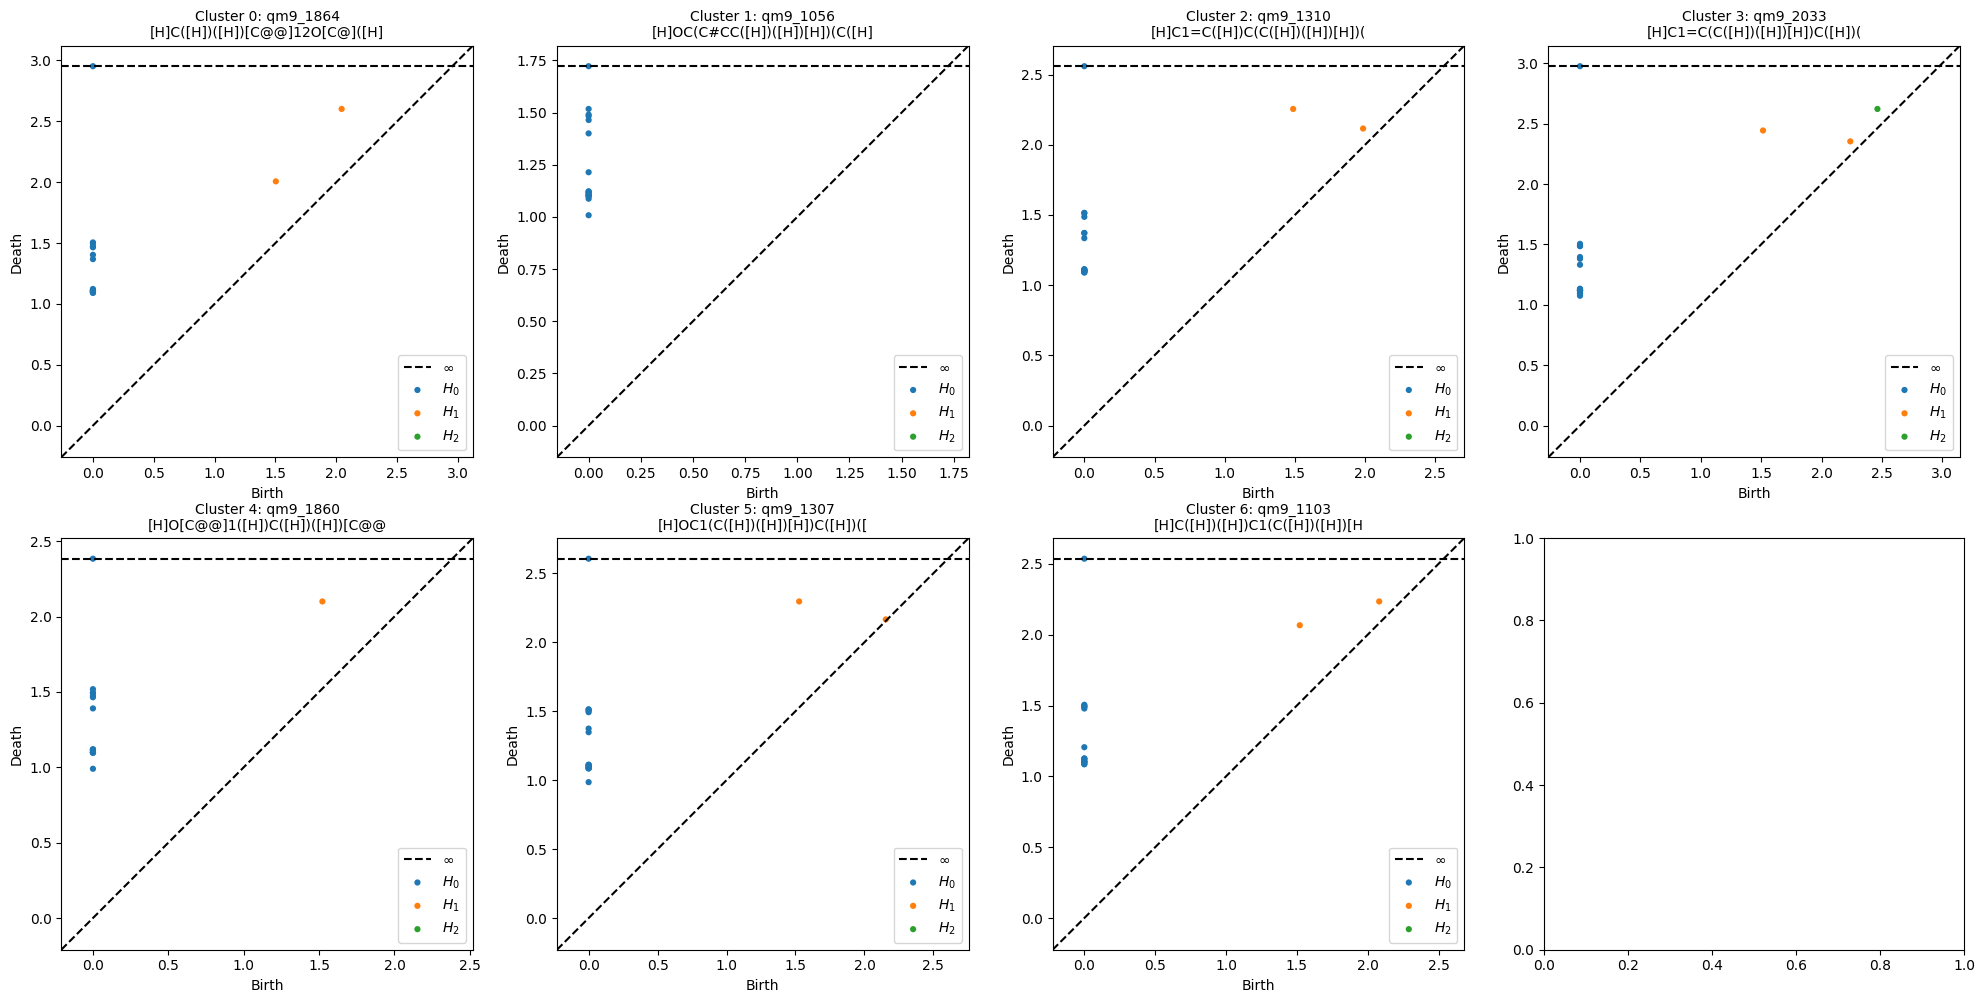

In [19]:
diagrams = PersistentHomology.compute_persistence_diagrams(frames)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

unique_clusters = sorted(isomers_df["cluster_ph"].unique().to_list())
n = 0

for i, cluster_nr in enumerate(unique_clusters):
    cluster_sample = isomers_df.with_row_index().filter(pl.col("cluster_ph") == cluster_nr).head(1)
    
    idx = cluster_sample["index"][n]
    mol_id = cluster_sample["mol_id"][n]
    smiles = cluster_sample["smiles"][n]
    
    dgms_dict = diagrams[idx]
    dgms = [dgms_dict.get(dim, np.empty((0, 2))) for dim in range(3)]
    
    plt.sca(axes[i])
    plot_diagrams(dgms, show=False)
    axes[i].set_title(f"Cluster {cluster_nr}: {mol_id}\n{smiles[:30]}", fontsize=10)



plt.tight_layout()
plt.show()


# SOAP

In [20]:
properties = {
    "UMAP 1": X_soap_t[:, 0],
    "UMAP 2": X_soap_t[:, 1],
    "Cluster": labels_soap,
    "Structure": isomers_df["structure_class"].to_list(),
    "Functional Groups":  isomers_df["functional_groups"].to_list(),
    "SP1 Carbon" : isomers_df["num_sp_carbons"].to_list(),
    "SP2 Carbon" : isomers_df["num_sp2_carbons"].to_list(),
    "SP3 Carbon" : isomers_df["num_sp3_carbons"].to_list(),
}

widget = chemiscope.show(
    structures=frames,
    properties=properties,
)

widget

<ChemiscopeWidget(meta={'name': ' '}, structures=[{'size': 17, 'data': 'structure-0'}, {'size': 17, 'data': 's…